# Freight Rate Prediction — ML Assessment

This notebook contains data exploration, preprocessing, time-based validation,
model comparison, final training, and prediction generation.

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

pd.set_option("display.max_columns", None)

DATA_DIR = Path("/content/drive/MyDrive")

TRAIN_PATH = DATA_DIR / "train-test.csv"
VALIDATION_PATH = DATA_DIR / "validation.csv"
TEMPLATE_PATH = DATA_DIR / "validation-predictions-template.csv"
DECEMBER_PATH = DATA_DIR / "december-chart-inputs.csv"

PROJECT_DIR = DATA_DIR / "spotter_ml_assessment"
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/spotter_ml_assessment


## 1. Load Data


In [3]:
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)

train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

print("\nTrain period:")
print(train["date"].min(), "→", train["date"].max())

print("\nValidation period:")
print(validation["date"].min(), "→", validation["date"].max())

train.head()

Train shape: (48000, 14)
Validation shape: (12000, 13)

Train period:
2025-01-01 00:00:00 → 2025-10-31 00:00:00

Validation period:
2025-11-01 00:00:00 → 2025-12-31 00:00:00


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2. Data Audit and Exploratory Data Analysis

In [4]:
print("Missing values — Train:")
display(train.isna().sum()[lambda x: x > 0])

print("\nMissing values — Validation:")
display(validation.isna().sum()[lambda x: x > 0])

print("\nDuplicate rows:", train.duplicated().sum())
print("Duplicate load IDs:", train["load_id"].duplicated().sum())

print("\nNegative weights:")
print("Train:", (train["weight"] < 0).sum())
print("Validation:", (validation["weight"] < 0).sum())

Missing values — Train:


,0
weight,300
market_index,374



Missing values — Validation:


,0
weight,165
market_index,249



Duplicate rows: 0
Duplicate load IDs: 0

Negative weights:
Train: 292
Validation: 145


In [8]:
train["posted_rate"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)


,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
1%,327.168800
5%,599.738500
25%,1251.555000
50%,2030.760000
75%,3330.750000
95%,4953.766500


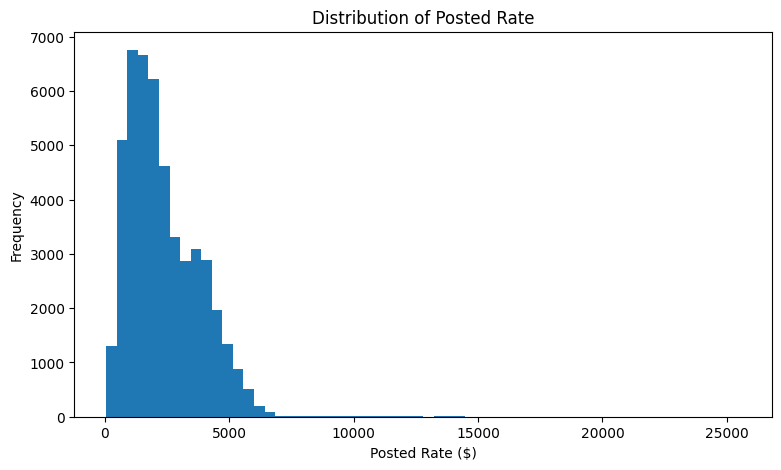

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(train["posted_rate"], bins=60)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Frequency")
plt.show()

In [9]:
Q1 = train["posted_rate"].quantile(0.25)
Q3 = train["posted_rate"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

target_outliers = train[
    train["posted_rate"] > upper_bound
]

print("IQR upper bound:", upper_bound)
print("High-rate observations:", len(target_outliers))

IQR upper bound: 6449.5425000000005
High-rate observations: 260


In [10]:
print(
    train.corr(numeric_only=True)["posted_rate"]
    .sort_values(ascending=False)
)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


In [11]:
display(
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median"])
)

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Flatbed,8753,2445.087223,2076.810
Reefer,12045,2553.636939,2196.670


In [12]:
for col in ["pickup", "delivery", "equipment"]:
    train_values = set(train[col].dropna())
    validation_values = set(validation[col].dropna())

    unseen = validation_values - train_values

    print(f"\n{col}")
    print("Train unique:", len(train_values))
    print("Validation unique:", len(validation_values))
    print("Unseen in validation:", len(unseen))

    if unseen:
        print(sorted(unseen))


pickup
Train unique: 64
Validation unique: 72
Unseen in validation: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

delivery
Train unique: 64
Validation unique: 72
Unseen in validation: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

equipment
Train unique: 3
Validation unique: 3
Unseen in validation: 0


In [13]:
train_routes = (
    train["pickup"].astype(str)
    + "__"
    + train["delivery"].astype(str)
)

validation_routes = (
    validation["pickup"].astype(str)
    + "__"
    + validation["delivery"].astype(str)
)

print("Train routes:", train_routes.nunique())
print("Validation routes:", validation_routes.nunique())

unseen_routes = (
    set(validation_routes)
    - set(train_routes)
)

print("Unseen validation routes:", len(unseen_routes))

Train routes: 4014
Validation routes: 4214
Unseen validation routes: 736


## 3. Cleaning and Feature Engineering

In [14]:
def prepare_data(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    # Negative weights are physically invalid but their magnitudes are plausible.
    df["weight"] = df["weight"].abs()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = (
        df["date"].dt.isocalendar().week.astype(int)
    )

    df["route"] = (
        df["pickup"].astype(str)
        + "__"
        + df["delivery"].astype(str)
    )

    return df

In [15]:
development = prepare_data(train)

train_part = development[
    development["date"] < "2025-10-01"
].copy()

valid_part = development[
    development["date"] >= "2025-10-01"
].copy()

print(
    "Training:",
    train_part["date"].min(),
    "→",
    train_part["date"].max()
)

print(
    "Local validation:",
    valid_part["date"].min(),
    "→",
    valid_part["date"].max()
)

print("Train rows:", len(train_part))
print("Validation rows:", len(valid_part))

Training: 2025-01-01 00:00:00 → 2025-09-30 00:00:00
Local validation: 2025-10-01 00:00:00 → 2025-10-31 00:00:00
Train rows: 43147
Validation rows: 4853


## 4. Model Features and Evaluation

In [16]:
TARGET = "posted_rate"

numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment",
]

cat_features_route = [
    "pickup",
    "delivery",
    "equipment",
    "route",
]

catboost_features_route = (
    numeric_features
    + cat_features_route
)

X_train = train_part[numeric_features + categorical_features]
X_valid = valid_part[numeric_features + categorical_features]

y_train = train_part[TARGET]
y_valid = valid_part[TARGET]

In [17]:
model_results = []

def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    r2 = r2_score(y_true, predictions)

    result = {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    model_results.append(result)

    print(model_name)
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")

    return result

## 5. Baseline Models


In [18]:
mean_prediction = y_train.mean()

mean_predictions = np.full(
    len(y_valid),
    mean_prediction
)

evaluate_model(
    "Mean Baseline",
    y_valid,
    mean_predictions
)

Mean Baseline
MAE:  1179.7960
RMSE: 1528.5669
R²:   -0.0000


{'model': 'Mean Baseline',
 'MAE': 1179.7959780864721,
 'RMSE': np.float64(1528.5669372257873),
 'R2': -1.3619235832651455e-05}

In [19]:
median_prediction = y_train.median()

median_predictions = np.full(
    len(y_valid),
    median_prediction
)

evaluate_model(
    "Median Baseline",
    y_valid,
    median_predictions
)

Median Baseline
MAE:  1146.7937
RMSE: 1567.9705
R²:   -0.0522


{'model': 'Median Baseline',
 'MAE': 1146.7937069853701,
 'RMSE': np.float64(1567.9704854490194),
 'R2': -0.05223503666552376}

In [20]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_valid)

evaluate_model(
    "Linear Regression",
    y_valid,
    linear_predictions
)

Linear Regression
MAE:  141.5826
RMSE: 651.3124
R²:   0.8184


{'model': 'Linear Regression',
 'MAE': 141.58259443683832,
 'RMSE': np.float64(651.3123797408479),
 'R2': 0.8184418881223128}

## 6. Linear Regression

In [21]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_valid)

evaluate_model(
    "Linear Regression",
    y_valid,
    linear_predictions
)

Linear Regression
MAE:  141.5826
RMSE: 651.3124
R²:   0.8184


{'model': 'Linear Regression',
 'MAE': 141.58259443683832,
 'RMSE': np.float64(651.3123797408479),
 'R2': 0.8184418881223128}

### Linear Regression Error Analysis

In [22]:
linear_errors = valid_part[
    [
        "load_id",
        "date",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "posted_rate",
    ]
].copy()

linear_errors["predicted_rate"] = linear_predictions

linear_errors["absolute_error"] = (
    linear_errors["posted_rate"]
    - linear_errors["predicted_rate"]
).abs()

linear_errors["residual"] = (
    linear_errors["posted_rate"]
    - linear_errors["predicted_rate"]
)

display(
    linear_errors.sort_values(
        "absolute_error",
        ascending=False
    ).head(20)
)

,load_id,date,pickup,delivery,distance,equipment,weight,posted_rate,predicted_rate,absolute_error,residual
43539,TR-043540,2025-10-03,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,17514.11,3680.372930,13833.737070,13833.737070
46213,TR-046214,2025-10-20,Columbia,Tucson,2023.4,Flatbed,34710.0,17893.17,4128.004572,13765.165428,13765.165428
47298,TR-047299,2025-10-27,Boston,Bakersfield,2979.1,Reefer,30585.0,19110.30,5982.981902,13127.318098,13127.318098
46516,TR-046517,2025-10-22,Toledo,Albuquerque,1684.3,Reefer,31536.0,14784.38,3598.859115,11185.520885,11185.520885
46366,TR-046367,2025-10-21,Bakersfield,Columbia,2251.9,Dry Van,40729.0,14403.14,4438.350454,9964.789546,9964.789546
47536,TR-047537,2025-10-29,Los Angeles,Richmond,2782.4,Dry Van,25730.0,15003.55,5321.132077,9682.417923,9682.417923
44267,TR-044268,2025-10-08,Albany,Albuquerque,2492.6,Dry Van,25513.0,14425.42,4777.416489,9648.003511,9648.003511
43302,TR-043303,2025-10-01,Atlanta,Phoenix,2083.1,Reefer,40335.0,13894.55,4367.353519,9527.196481,9527.196481
43384,TR-043385,2025-10-02,Lexington,Lubbock,1187.0,Dry Van,25359.0,11696.44,2428.685867,9267.754133,9267.754133
47586,TR-047587,2025-10-29,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,11596.28,2938.606366,8657.673634,8657.673634


## 7. Random Forest

In [ ]:
rf_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

rf_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", rf_numeric_pipeline, numeric_features),
        ("cat", rf_categorical_pipeline, categorical_features),
    ]
)

random_forest = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_valid)

evaluate_model(
    "Random Forest",
    y_valid,
    rf_predictions
)

## 8. CatBoost


In [25]:
base_cat_features = [
    "pickup",
    "delivery",
    "equipment",
]

base_catboost_features = (
    numeric_features
    + base_cat_features
)

X_train_cat = train_part[
    base_catboost_features
].copy()

X_valid_cat = valid_part[
    base_catboost_features
].copy()

for col in base_cat_features:
    X_train_cat[col] = X_train_cat[col].astype(str)
    X_valid_cat[col] = X_valid_cat[col].astype(str)

catboost_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="MAE",
    task_type="CPU",
    thread_count=-1,
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=base_cat_features,
    eval_set=(X_valid_cat, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

cat_predictions = catboost_model.predict(
    X_valid_cat
)

evaluate_model(
    "CatBoost",
    y_valid,
    cat_predictions
)

CatBoost
MAE:  118.7990
RMSE: 647.4172
R²:   0.8206


{'model': 'CatBoost',
 'MAE': 118.79895110197717,
 'RMSE': np.float64(647.4171723260649),
 'R2': 0.820607029713271}

## 9. CatBoost with Route Feature

In [26]:
X_train_route = train_part[
    catboost_features_route
].copy()

X_valid_route = valid_part[
    catboost_features_route
].copy()

for col in cat_features_route:
    X_train_route[col] = (
        X_train_route[col].astype(str)
    )

    X_valid_route[col] = (
        X_valid_route[col].astype(str)
    )

catboost_route_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="MAE",
    task_type="CPU",
    thread_count=-1,
    random_seed=42,
    verbose=False
)

catboost_route_model.fit(
    X_train_route,
    y_train,
    cat_features=cat_features_route,
    eval_set=(X_valid_route, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

cat_route_predictions = (
    catboost_route_model.predict(
        X_valid_route
    )
)

evaluate_model(
    "CatBoost + Route",
    y_valid,
    cat_route_predictions
)

CatBoost + Route
MAE:  120.1798
RMSE: 648.9665
R²:   0.8197


{'model': 'CatBoost + Route',
 'MAE': 120.17979228997427,
 'RMSE': np.float64(648.9665342767771),
 'R2': 0.8197473762010177}

## 10. Model Comparison

In [27]:
model_results_df = pd.DataFrame(
    model_results
).drop_duplicates(
    subset="model",
    keep="last"
)

model_results_df = (
    model_results_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(model_results_df)

model_results_df.to_csv(
    PROJECT_DIR / "model_results.csv",
    index=False
)

,model,MAE,RMSE,R2
0,CatBoost,118.798951,647.417172,0.820607
1,CatBoost + Route,120.179792,648.966534,0.819747
2,Linear Regression,141.582594,651.312380,0.818442
3,Median Baseline,1146.793707,1567.970485,-0.052235
4,Mean Baseline,1179.795978,1528.566937,-0.000014


## 11. Rolling Time-Based Validation

In [28]:
def build_catboost_route():
    return CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="MAE",
        task_type="GPU",
        devices="0",
        random_seed=42,
        verbose=False
    )


def evaluate_time_split(
    data,
    train_end,
    valid_start,
    valid_end
):
    train_split = data[
        data["date"] <= train_end
    ].copy()

    valid_split = data[
        (data["date"] >= valid_start)
        & (data["date"] <= valid_end)
    ].copy()

    X_tr = train_split[
        catboost_features_route
    ].copy()

    X_va = valid_split[
        catboost_features_route
    ].copy()

    y_tr = train_split[TARGET]
    y_va = valid_split[TARGET]

    for col in cat_features_route:
        X_tr[col] = X_tr[col].astype(str)
        X_va[col] = X_va[col].astype(str)

    model = build_catboost_route()

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features_route,
        eval_set=(X_va, y_va),
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=False
    )

    predictions = model.predict(X_va)

    return {
        "MAE": mean_absolute_error(
            y_va,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_va,
                predictions
            )
        ),
        "R2": r2_score(
            y_va,
            predictions
        ),
    }

## 12. Limited Hyperparameter Tuning

In [31]:
configs = [
    {
        "name": "CatBoost d7",
        "depth": 7,
        "learning_rate": 0.05,
        "iterations": 1500,
    },
    {
        "name": "CatBoost lr003",
        "depth": 8,
        "learning_rate": 0.03,
        "iterations": 2000,
    },
    {
        "name": "CatBoost d9",
        "depth": 9,
        "learning_rate": 0.05,
        "iterations": 1500,
    },
]

tuning_results = []

for config in configs:

    model = CatBoostRegressor(
        iterations=config["iterations"],
        learning_rate=config["learning_rate"],
        depth=config["depth"],
        loss_function="RMSE",
        eval_metric="MAE",
        task_type="CPU",
        thread_count=-1,
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train_route,
        y_train,
        cat_features=cat_features_route,
        eval_set=(X_valid_route, y_valid),
        use_best_model=True,
        early_stopping_rounds=100
    )

    predictions = model.predict(
        X_valid_route
    )

    tuning_results.append({
        "model": config["name"],
        "depth": config["depth"],
        "learning_rate":
            config["learning_rate"],
        "best_iteration":
            model.get_best_iteration(),
        "MAE":
            mean_absolute_error(
                y_valid,
                predictions
            ),
        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_valid,
                    predictions
                )
            ),
        "R2":
            r2_score(
                y_valid,
                predictions
            ),
    })

tuning_df = pd.DataFrame(
    tuning_results
).sort_values("MAE")

display(tuning_df)

tuning_df.to_csv(
    PROJECT_DIR / "tuning_results.csv",
    index=False
)

,model,depth,learning_rate,best_iteration,MAE,RMSE,R2
1,CatBoost lr003,8,0.03,316,112.815651,646.855009,0.820918
0,CatBoost d7,7,0.05,141,117.221866,648.342134,0.820094
2,CatBoost d9,9,0.05,137,117.262620,648.030346,0.820267


## 13. Feature Importance

,feature,importance
4,distance,87.624794
15,equipment,4.797781
5,weight,1.451548
6,market_index,1.088721
12,week_of_year,0.847680
7,quote_signal,0.754180
9,month,0.677330
14,delivery,0.624807
13,pickup,0.423059
2,delivery_lat,0.416272


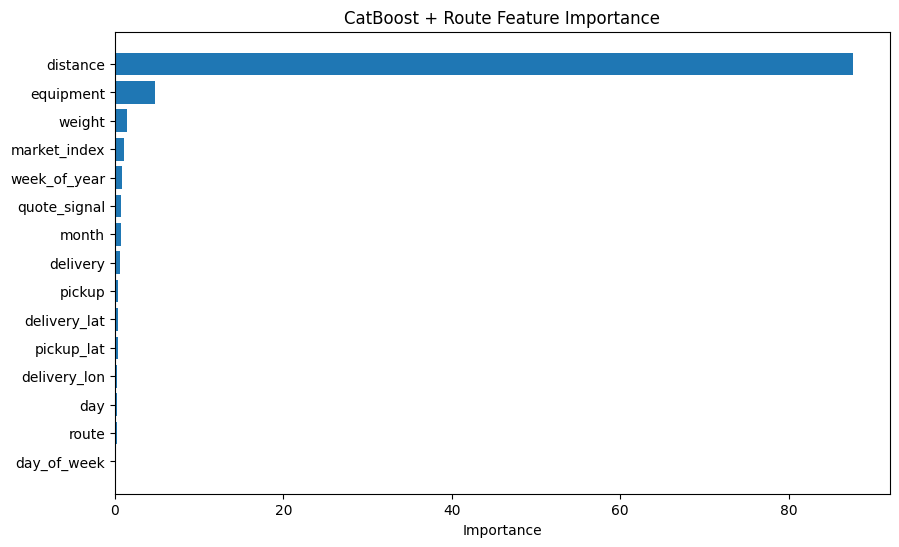

In [32]:
feature_importance = pd.DataFrame({
    "feature":
        catboost_route_model.feature_names_,
    "importance":
        catboost_route_model.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title(
    "CatBoost + Route Feature Importance"
)
plt.xlabel("Importance")
plt.show()

## 14. Final Model Training

In [34]:
final_train = prepare_data(train)

X_final_train = final_train[
    catboost_features_route
].copy()

y_final_train = final_train[
    TARGET
].copy()

for col in cat_features_route:
    X_final_train[col] = (
        X_final_train[col].astype(str)
    )

final_model = CatBoostRegressor(
    iterations=164,
    learning_rate=0.05,
    depth=9,
    loss_function="RMSE",
    task_type="CPU",
    thread_count=-1,
    random_seed=42,
    verbose=False
)

final_model.fit(
    X_final_train,
    y_final_train,
    cat_features=cat_features_route
)

final_model.save_model(
    str(
        PROJECT_DIR
        / "final_catboost_model.cbm"
    )
)

print(
    "Final model trained on",
    len(final_train),
    "rows."
)

Final model trained on 48000 rows.


## 15. Final Validation Predictions

In [35]:
validation_final = prepare_data(
    validation
)

X_final_validation = validation_final[
    catboost_features_route
].copy()

for col in cat_features_route:
    X_final_validation[col] = (
        X_final_validation[col].astype(str)
    )

final_predictions = final_model.predict(
    X_final_validation
)

print(
    "Number of predictions:",
    len(final_predictions)
)

Number of predictions: 12000


In [36]:
submission = pd.read_csv(
    TEMPLATE_PATH
)

submission["predicted_rate"] = (
    final_predictions
)

submission.to_csv(
    PROJECT_DIR
    / "validation_predictions.csv",
    index=False
)

print("Shape:", submission.shape)
print(submission.columns.tolist())

display(submission.head())

Shape: (12000, 2)
['load_id', 'predicted_rate']


,load_id,predicted_rate
0,TE-000001,889.884322
1,TE-000002,4965.079224
2,TE-000003,5257.520113
3,TE-000004,4068.276168
4,TE-000005,1793.696126


## 16. Fixed December Scenario

In [37]:
december_original = pd.read_csv(
    DECEMBER_PATH
)

december = prepare_data(
    december_original
)

In [38]:
pickup_coordinates = (
    final_train[
        [
            "pickup",
            "pickup_lat",
            "pickup_lon",
        ]
    ]
    .drop_duplicates("pickup")
    .set_index("pickup")
)

delivery_coordinates = (
    final_train[
        [
            "delivery",
            "delivery_lat",
            "delivery_lon",
        ]
    ]
    .drop_duplicates("delivery")
    .set_index("delivery")
)

december["pickup_lat"] = (
    december["pickup"].map(
        pickup_coordinates[
            "pickup_lat"
        ]
    )
)

december["pickup_lon"] = (
    december["pickup"].map(
        pickup_coordinates[
            "pickup_lon"
        ]
    )
)

december["delivery_lat"] = (
    december["delivery"].map(
        delivery_coordinates[
            "delivery_lat"
        ]
    )
)

december["delivery_lon"] = (
    december["delivery"].map(
        delivery_coordinates[
            "delivery_lon"
        ]
    )
)

december["market_index"] = (
    final_train[
        "market_index"
    ].median()
)

december["quote_signal"] = (
    final_train[
        "quote_signal"
    ].median()
)

In [39]:
missing_december_features = (
    december[
        catboost_features_route
    ]
    .isna()
    .sum()
)

print(missing_december_features)

pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
weight          0
market_index    0
quote_signal    0
year            0
month           0
day             0
day_of_week     0
week_of_year    0
pickup          0
delivery        0
equipment       0
route           0
dtype: int64


In [40]:
X_december = december[
    catboost_features_route
].copy()

for col in cat_features_route:
    X_december[col] = (
        X_december[col].astype(str)
    )

december_predictions = (
    final_model.predict(
        X_december
    )
)

In [41]:
december_output = (
    december_original.copy()
)

december_output[
    "predicted_rate"
] = december_predictions

december_output.to_csv(
    PROJECT_DIR
    / "december_predictions.csv",
    index=False
)

print(
    december_output.shape
)

print(
    december_output.columns.tolist()
)

display(
    december_output.head()
)

(31, 7)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,862.412763
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,864.937564
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,871.151487
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,870.044459
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,866.103577


## 17. Submission Validation

In [43]:
!python score.py \
  --predictions "/content/drive/MyDrive/spotter_ml_assessment/validation_predictions.csv" \
  --december-predictions "/content/drive/MyDrive/spotter_ml_assessment/december_predictions.csv" \
  --output-dir "/content/drive/MyDrive/spotter_ml_assessment/scorer_results"

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: /content/drive/MyDrive/spotter_ml_assessment/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
